In [1]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load Data

In [2]:
data_dir = Path('/g/data/gb02/cd3022/hot-and-cloudy/solar-pv/GCCSA/ideal-actual')
files = list(data_dir.glob("*.nc"))
datasets = []

for file in files:
    region_name = file.stem[1:5]
    ds_reg = xr.open_dataset(file)
    ds_reg = ds_reg.expand_dims(region=[region_name])

    datasets.append(ds_reg)

ds = xr.concat(datasets, dim='region')

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.06/share/proj failed


# Preprocessing

- Change time zone to Brisbane loca time (as per NEM operation)
- Remove The missing time step each day where Himawari does maintanence
- Remove three days with bad himawari data (error in processing NWP data for the irradiance calculations)
- Convert power data into capacity factor data
    - Normalize the power output to the rated capacity of the solar panel (219.656729124 W/m2)

In [3]:
# Change times to AEST
time_utc = pd.to_datetime(ds.time.values)
time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)
ds = ds.assign_coords(time=("time", time_aest_naive))

ds = ds.where(ds['time'].dt.strftime('%H:%M') != '12:40', drop=True)

bad_days = [
    np.datetime64('2019-08-12'),
    np.datetime64('2019-10-01'),
    np.datetime64('2020-09-06'),
    
]
ds_dates = ds['time'].dt.floor('D')
good_time_mask = ~ds_dates.isin(bad_days)
ds = ds.sel(time=ds['time'][good_time_mask])

rated_capacity = 219.656729124
ds = ds.apply(lambda x: x / rated_capacity)

ds = xr.where(ds.isnull(), 0, ds)

# Data Description

This dataset has two important variables:
- Solar PV output from Himawari irradiance input (actual)
- Solar PV output from estimated clearsky irradiance input (ideal)

The clear sky irradiance is estimate using the Ineichen model. For more details, see below:
- Description of the clear sky model
    - https://www.sciencedirect.com/science/article/abs/pii/S0038092X02000452
- PVLib docs
    - https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.clearsky.ineichen.html

- Verification of PVLib irradiance models
    - https://www.sciencedirect.com/science/article/pii/S3050475925000363


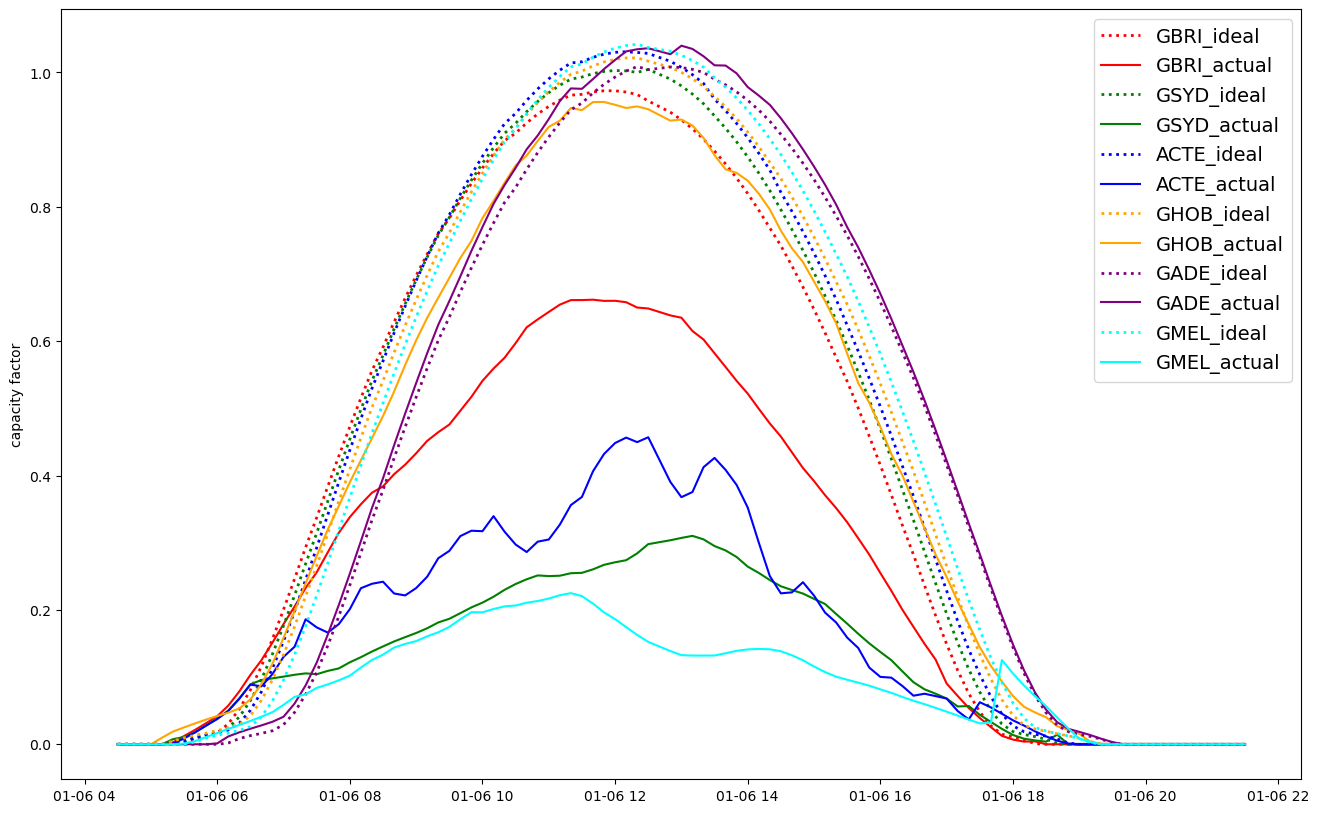

In [4]:
date = '2020-01-06'
plt.figure(figsize=(16,10))
colours = ['red', 'green', 'blue', 'orange', 'purple', 'cyan']
for i, reg in enumerate(ds.region):
    data_ideal = ds.ideal.sel(time=date, region=reg)
    data_actual = ds.actual.sel(time=date, region=reg)
    
    plt.plot(data_ideal.time, data_ideal, label=f'{reg.data}_ideal', ls=':', lw=2, c=colours[i])
    plt.plot(data_actual.time, data_actual, label=f'{reg.data}_actual', ls='-', c=colours[i])
    plt.legend(fontsize=14)
    plt.ylabel('capacity factor')

# Clear Sky Index

Taking the ratio of actual to ideal irradiance gives a measure of the cloudiness, where 1 indicates the actual irradiance is representative of clear sky conditions, 0.5 suggests that approximately half the the irradiance is being extinguished by clouds etc. I refer to this measure as the clear sky index (CSI). I say "approximately" because the estimated clear sky irradiance is not perfect (e.g. there are many days with actual > ideal), but for the purposes of identifying very cloudy times/days it should be appropriate.

For assessing the instaneous CSI it is appropriate to take the ratio of the instaneous data,

$${\text{CSI}} = \frac{P_\text{actual}} {P_\text{ideal}}$$

so that regardless of the time of day the results are always relative to the ideal conditions, i.e. if the clouds remain the same throughout the day then the CSI should also remain the same, even as the angle of the sun on the panel changes. This is useful for some use cases, but not always. For example, if we were interested in the total potential solar energy generation over the day then simply integrating CSI would give misleading results. Instead, in this case it is more appropriate to integrate the actual and ideal data separately and then take their ratio

$${\text{CSI}}_{\text{daily}} = \frac{\int_{0}^{24 hr} {P_\text{actual}(t)} \ dt}{\int_{0}^{24hr} {P_\text{ideal}(t)} \ dt}$$

so that we get a daily CSI that represents the potential for solar energy generation on this day, relative to a comparable day with no clouds.

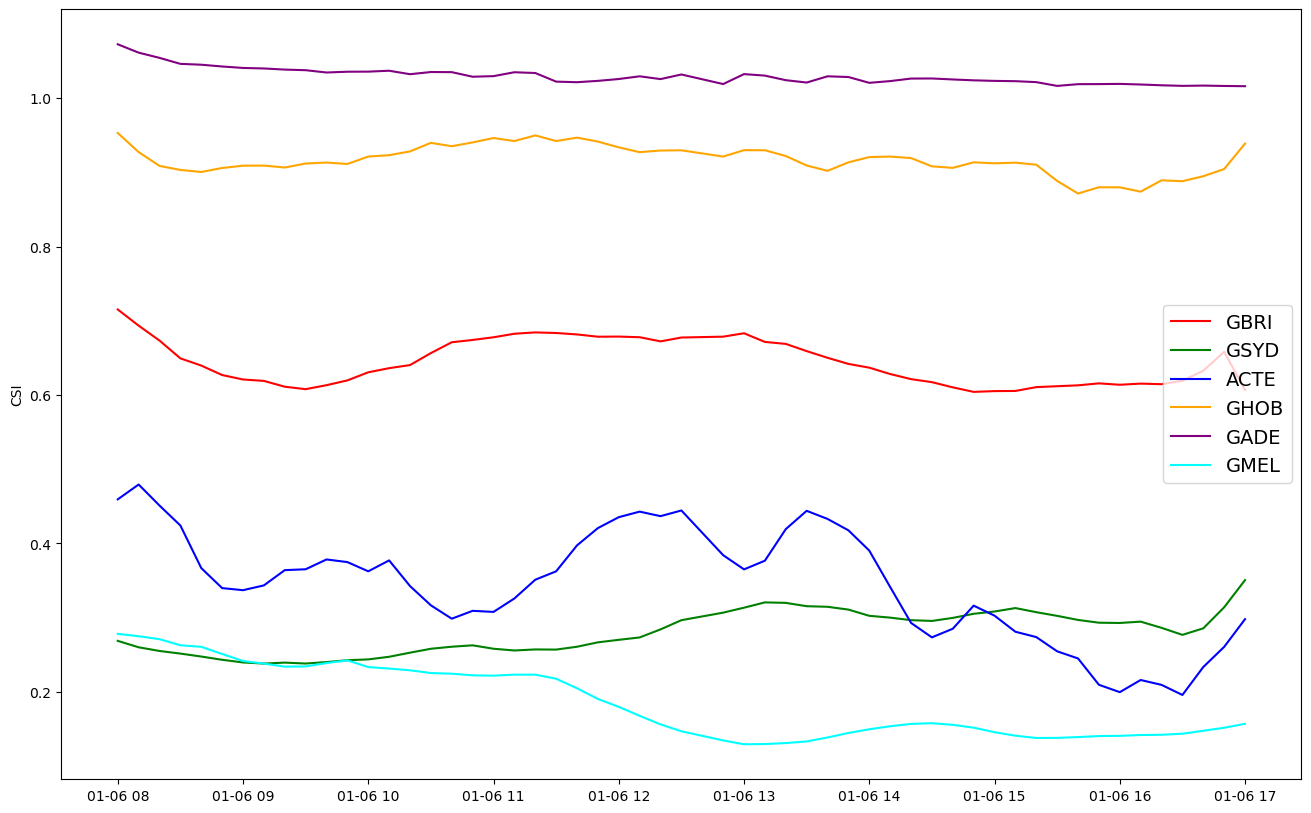

In [16]:
# Example of the instantaneous CSI accross the day

date = '2020-01-06'
# Just looking at 8am to 5pm
time_start = '0800'
time_end = '1700'
plt.figure(figsize=(16,10))
colours = ['red', 'green', 'blue', 'orange', 'purple', 'cyan']
for i, reg in enumerate(ds.region):
    data_ideal = ds.ideal.sel(time=slice(f'{date}T{time_start}',f'{date}T{time_end}'), region=reg)
    data_actual = ds.actual.sel(time=slice(f'{date}T{time_start}',f'{date}T{time_end}'), region=reg)
    CSI = data_actual / data_ideal
    
    plt.plot(CSI.time, CSI, label=f'{reg.data}', ls='-', c=colours[i])
    plt.legend(fontsize=14)
    plt.ylabel('CSI')

# Find Cloudy Days

Using the daily CSI definition above, we can set a threshold for what we consider a "cloudy" day and then find days that fall below this.

This is a simple definition that only considers the cumulative daily cloudiness. We might also be interested in days that have a sudden change in the cloudiness, are very cloudy for X number of hours, or some other sub-daily feature.

In [57]:
threshold = 0.3

for reg in ds.region:

    daily_actual = ds.actual.sel(region=reg).resample(time='1D').map(
        lambda x: x.integrate(coord='time')
    )
    daily_ideal = ds.ideal.sel(region=reg).resample(time='1D').map(
        lambda x: x.integrate(coord='time')
    )
    CSI = daily_actual / daily_ideal
    warm_months = [1,2,3,11,12]
    csi_warm_months = CSI.where(CSI.time.dt.month.isin(warm_months), drop=True)

    cloudy_days = csi_warm_months.where(csi_warm_months < threshold, drop=True).time
    print(f'Cloudy days for: {reg.data}')
    print(cloudy_days.data) 

Cloudy days for: GBRI
['2015-12-02T00:00:00.000000000' '2015-12-12T00:00:00.000000000'
 '2016-01-05T00:00:00.000000000' '2016-01-16T00:00:00.000000000'
 '2016-01-28T00:00:00.000000000' '2016-02-04T00:00:00.000000000'
 '2016-03-27T00:00:00.000000000' '2017-03-20T00:00:00.000000000'
 '2017-03-30T00:00:00.000000000' '2017-11-18T00:00:00.000000000'
 '2017-12-04T00:00:00.000000000' '2018-02-01T00:00:00.000000000'
 '2018-02-02T00:00:00.000000000' '2018-02-03T00:00:00.000000000'
 '2018-02-22T00:00:00.000000000' '2018-02-23T00:00:00.000000000'
 '2018-12-16T00:00:00.000000000' '2019-03-27T00:00:00.000000000'
 '2019-03-30T00:00:00.000000000' '2020-02-04T00:00:00.000000000'
 '2020-02-05T00:00:00.000000000' '2020-02-06T00:00:00.000000000'
 '2020-02-13T00:00:00.000000000' '2020-02-23T00:00:00.000000000'
 '2020-03-09T00:00:00.000000000' '2020-03-24T00:00:00.000000000'
 '2020-12-11T00:00:00.000000000' '2020-12-13T00:00:00.000000000'
 '2020-12-14T00:00:00.000000000' '2020-12-30T00:00:00.000000000'
 '2